In [1]:
# ============================================================================
# CELL 1: ENVIRONMENT CHECK
# ============================================================================

import warnings, sys, os
warnings.filterwarnings("ignore")

import torch

print(f"Python  : {sys.version.split()[0]}")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    cap = torch.cuda.get_device_capability(0)
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"sm_     : {cap[0]}{cap[1]}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB")
    if cap[0] < 7:
        print()
        print("WARNING: P100 sm_60 is incompatible with this torch build.")
        print("Change Kaggle Accelerator to T4/P4 for GPU training.")
        print("CPU training will work but is slow.")
else:
    print("No CUDA GPU.")


Python  : 3.12.12
PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4
sm_     : 75
VRAM    : 14.6 GB


In [9]:
# ============================================================================
# CELL 3: IMPORT LIBRARIES
# ============================================================================
!pip install numpy pandas matplotlib seaborn opencv-python pillow scikit-learn scipy ultralytics gymnasium
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
from PIL import Image
from pathlib import Path
from sklearn.cluster import DBSCAN
from scipy.ndimage import gaussian_filter
import shutil, yaml, random, os, time
from collections import defaultdict

from ultralytics import YOLO

import gymnasium as gym
from gymnasium import spaces

try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    plt.style.use('ggplot')
sns.set_palette("husl")
np.random.seed(42)
random.seed(42)

print("✅ All libraries imported!")


✅ All libraries imported!


 MH-WEED16 DATASET PREPARATION (Binary: Weed vs Non-Weed)

Image Directory : /kaggle/input/datasets/psycho358/mh-weed16/MH-Weed/intel Real Sense Depth_Clicks/intel Real Sense Depth_Clicks
Label Directory : /kaggle/input/datasets/psycho358/mh-weed16/MH-Weed/intel Real Sense Depth_Annotations/intel Real Sense Depth_Annotations/YOLO_darknet

✅ Total Images Found: 6656
✅ Valid image-label pairs : 6656
⚠️  Missing labels          : 0

📊 Original Class Distribution:
  Class  0:  6512 instances
  Class  1: 22739 instances
  Class  2: 22394 instances
  Class  3:  2217 instances
  Class  4:  1804 instances
  Class  5:  2278 instances
  Class  6:   181 instances
  Class  7:   214 instances
  Class  8:   836 instances
  Class  9:  1425 instances
  Class 10:   476 instances
  Class 11:   126 instances
  Class 12:   399 instances
  Class 13:   184 instances
  Class 14:   267 instances
  Total original classes: 15

🔄 Binary Remapping:
  Classes {0} → 0 (Non-Weed)
  All other classes       → 1 (Weed)

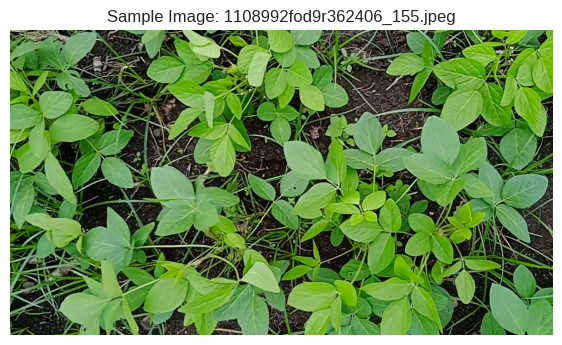

Sample Image Size: (1920, 1080)

 MH-Weed16 → Binary Dataset Ready for YOLO Training


In [ ]:
print("="*70)
print(" MH-WEED16 DATASET PREPARATION (Binary: Weed vs Non-Weed)")
print("="*70, "\n")

#    1. Paths            
image_dir = Path("/kaggle/input/datasets/psycho358/mh-weed16/MH-Weed/intel Real Sense Depth_Clicks/intel Real Sense Depth_Clicks")
label_dir = Path("/kaggle/input/datasets/psycho358/mh-weed16/MH-Weed/intel Real Sense Depth_Annotations/intel Real Sense Depth_Annotations/YOLO_darknet")

print(f"Image Directory : {image_dir}")
print(f"Label Directory : {label_dir}")

#    2. Load Images      
all_images = []
for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
    all_images.extend(list(image_dir.rglob(ext)))
print(f"\n✅ Total Images Found: {len(all_images)}")

if len(all_images) == 0:
    raise Exception("❌ No images found. Check your image path!")

#    3. Match Labels     
valid_pairs = []
missing_labels = 0
for img_path in all_images:
    label_path = label_dir / (img_path.stem + ".txt")
    if label_path.exists():
        valid_pairs.append((img_path, label_path))
    else:
        missing_labels += 1

print(f"✅ Valid image-label pairs : {len(valid_pairs)}")
print(f"⚠️  Missing labels          : {missing_labels}")

if len(valid_pairs) == 0:
    raise Exception("❌ No valid image-label pairs found!")

#    4. Analyze Original Class Distribution                                     
print("\n📊 Original Class Distribution:")
class_counts = defaultdict(int)
for _, label_path in valid_pairs:
    with open(label_path, "r") as f:
        for line in f:
            if line.strip():
                class_id = int(line.split()[0])
                class_counts[class_id] += 1
for cls_id, count in sorted(class_counts.items()):
    print(f"  Class {cls_id:2d}: {count:5d} instances")
print(f"  Total original classes: {len(class_counts)}")

#    5. Define Binary Remapping                                                 
#
# Update this set if your dataset uses different IDs for crop/background
CROP_CLASS_IDS = {0}   # Class 0 = Crop → Non-Weed (label 0)
                        # Everything else  → Weed    (label 1)

BINARY_CLASSES = ['Non-Weed', 'Weed']

def remap_label_line(line):
    """Remap a single YOLO label line to binary (0=Non-Weed, 1=Weed)."""
    parts = line.strip().split()
    if not parts:
        return None
    original_class = int(parts[0])
    binary_class   = 0 if original_class in CROP_CLASS_IDS else 1
    return f"{binary_class} " + " ".join(parts[1:])

print(f"\n🔄 Binary Remapping:")
print(f"  Classes {CROP_CLASS_IDS} → 0 (Non-Weed)")
print(f"  All other classes       → 1 (Weed)")

#    6. Train / Val / Test Split (70 / 20 / 10)                                 
random.shuffle(valid_pairs)
total       = len(valid_pairs)
train_split = int(0.7 * total)
val_split   = int(0.9 * total)

train_data = valid_pairs[:train_split]
val_data   = valid_pairs[train_split:val_split]
test_data  = valid_pairs[val_split:]

print(f"\n📂 Dataset Split:")
print(f"  Training   : {len(train_data)}")
print(f"  Validation : {len(val_data)}")
print(f"  Test       : {len(test_data)}")

#    7. Copy Images & Write Remapped Labels                                     
working_dir = Path("/kaggle/working/mhweed_binary_yolo")

for split_name, split_data in zip(
    ["train", "val", "test"],
    [train_data, val_data, test_data]
):
    (working_dir / "images" / split_name).mkdir(parents=True, exist_ok=True)
    (working_dir / "labels" / split_name).mkdir(parents=True, exist_ok=True)

    for img_path, label_path in split_data:
        # Copy image
        shutil.copy(img_path, working_dir / "images" / split_name / img_path.name)

        # Write binary-remapped label
        out_label = working_dir / "labels" / split_name / label_path.name
        with open(label_path, "r") as fin, open(out_label, "w") as fout:
            for line in fin:
                remapped = remap_label_line(line)
                if remapped:
                    fout.write(remapped + "\n")

print("\n✅ Binary YOLO folder structure created!")

#    8. Create data.yaml                                                        
data_yaml = {
    "path"  : str(working_dir),
    "train" : "images/train",
    "val"   : "images/val",
    "test"  : "images/test",
    "nc"    : 2,
    "names" : BINARY_CLASSES
}

yaml_path = working_dir / "data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f"\n✅ data.yaml created: {yaml_path}")
print(f"   Classes: {BINARY_CLASSES}")

#    9. Verify Binary Distribution                                             
print("\n📊 Binary Label Distribution (training set):")
binary_counts = defaultdict(int)
for _, label_path in train_data:
    out_label = working_dir / "labels" / "train" / label_path.name
    with open(out_label, "r") as f:
        for line in f:
            if line.strip():
                binary_counts[int(line.split()[0])] += 1
for cls_id, name in enumerate(BINARY_CLASSES):
    cnt = binary_counts.get(cls_id, 0)
    print(f"  Class {cls_id} ({name:10s}): {cnt:5d} instances")

#    10. Display Sample  
sample_img = Image.open(train_data[0][0])
plt.figure(figsize=(7, 5))
plt.imshow(sample_img)
plt.title(f"Sample Image: {train_data[0][0].name}")
plt.axis("off")
plt.show()
print(f"Sample Image Size: {sample_img.size}")

print("\n" + "="*70)
print(" MH-Weed16 → Binary Dataset Ready for YOLO Training")
print("="*70)

Found 16 CSV files: ['test_subset2.csv', 'train_subset1.csv', 'test_subset4.csv', 'train_subset4.csv', 'train_subset3.csv', 'val_subset2.csv', 'train_subset2.csv', 'test_subset1.csv', 'val_subset0.csv', 'val_subset4.csv', 'test_subset3.csv', 'test_subset0.csv', 'train_subset0.csv', 'val_subset3.csv', 'val_subset1.csv', 'labels.csv']
Total unique labelled images: 17509

Class distribution:
Label
0    1126
1    1063
2    1031
3    1022
4    1062
5    1009
6    1074
7    1016
8    9106

Label 8 = Negative (Non-Weed)  |  Labels 0-7 = Weed species

Non-Weed pool : 9106
Weed pool     : 8403

Selected: 3000 images
  Non-Weed : 1500
  Weed     : 1500


/tmp/ipykernel_55/3634622435.py:56: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(per_species, len(x)),


Final usable: 3000

Split: train=2100  val=600  test=300
Dataset written.

Training instance counts:
  Non-Weed (0) : 1054
  Weed     (1) : 1046
  Ratio        : 0.99x  ✅


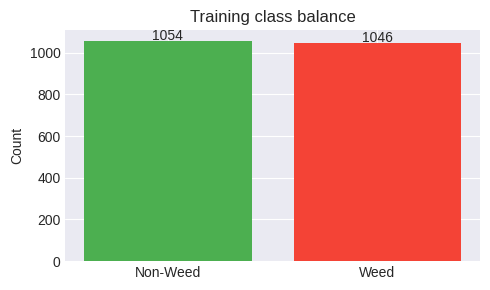

data.yaml: /kaggle/working/deepweeds_yolo/data.yaml

Device: cuda  AMP: True
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.39 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=1.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/deepweeds_yolo/data.yaml, degrees=15, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.65, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yo

In [ ]:
#    Step 9: TRAIN       
import torch
from ultralytics import YOLO

device  = "cuda" if (torch.cuda.is_available() and
                     torch.cuda.get_device_capability(0)[0] >= 7) else "cpu"
use_amp = device == "cuda"
print(f"\nDevice: {device}  AMP: {use_amp}")

model = YOLO("yolov8l.pt")   # l = good balance of speed vs accuracy for 3k images

model.train(
    data            = str(out/"data.yaml"),
    epochs          = 80,
    imgsz           = 640,
    batch           = 16,
    device          = device,
    workers         = 2,
    optimizer       = "AdamW",
    lr0             = 0.001,
    lrf             = 0.01,
    cos_lr          = True,
    weight_decay    = 0.0005,
    warmup_epochs   = 3,
    momentum        = 0.937,
    cls             = 1.0,
    iou             = 0.65,
    label_smoothing = 0.1,
    box             = 7.5,
    dropout         = 0.1,
    patience        = 20,
    val             = True,
    amp             = use_amp,
    hsv_h           = 0.015,
    hsv_s           = 0.7,
    hsv_v           = 0.4,
    degrees         = 15,
    translate       = 0.1,
    scale           = 0.5,
    flipud          = 0.3,
    fliplr          = 0.5,
    mosaic          = 1.0,
    mixup           = 0.1,
    close_mosaic    = 15,
    project         = "deepweeds_run",
    name            = "v1",
    exist_ok        = True,
    plots           = True,
    verbose         = True,
)

print("\nTraining complete!")

#    Conf sweep          
print("\n--- Conf sweep ---")
print(f"  {'Conf':>5}  {'Prec':>8}  {'Recall':>8}  {'F1':>8}  {'mAP50':>8}")
print("  " + "-"*48)

BEST_CONF = 0.25; best_f1 = 0.0; best_prec = 0.0

for conf in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    m  = model.val(data=str(out/"data.yaml"), conf=conf, iou=0.5, verbose=False)
    p, r, m50 = m.box.mp, m.box.mr, m.box.map50
    f1 = 2*p*r / (p+r+1e-9)
    tag = "  <-- best F1" if f1 > best_f1 else ""
    print(f"  {conf:.2f}   {p:8.4f}  {r:8.4f}  {f1:8.4f}  {m50:8.4f}{tag}")
    if f1 > best_f1:
        best_f1 = f1; BEST_CONF = conf; best_prec = p

print(f"\nResult: conf={BEST_CONF}  precision={best_prec:.4f}  F1={best_f1:.4f}")
print(f"Model : /kaggle/working/deepweeds_run/v1/weights/best.pt")

In [12]:
# ============================================================================
# CELL 6: SAVE BEST MODEL
# ============================================================================

from pathlib import Path
import shutil

best_model_path = Path("/kaggle/input/datasets/vanshj14/bestmodel/best.pt")
final_model_path = Path("/kaggle/working/mhweed_binary_best.pt")

shutil.copy(best_model_path, final_model_path)

print("✅ Model saved at:", final_model_path)
print(f"   Model size: {final_model_path.stat().st_size / (1024*1024):.2f} MB")

✅ Model saved at: /kaggle/working/mhweed_binary_best.pt
   Model size: 49.60 MB


✅ Model loaded from: /kaggle/working/runs/detect/deepweeds_run/v1/weights/best.pt


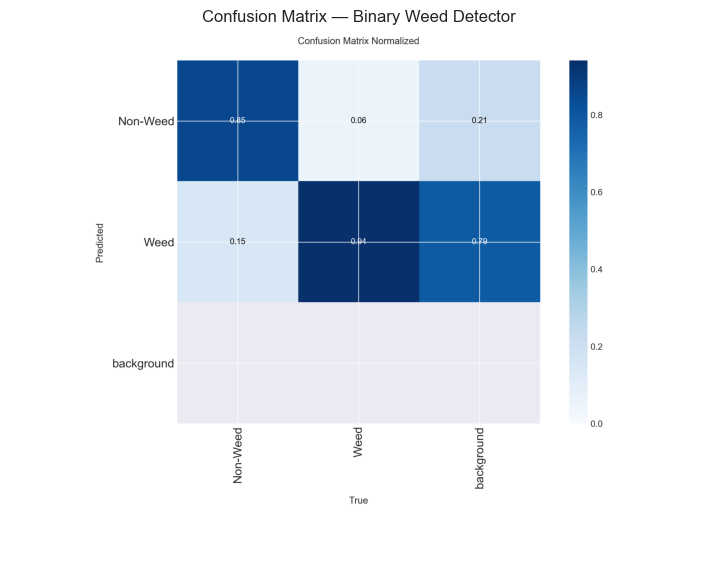

✅ Confusion matrix shown from: /kaggle/working/runs/detect/deepweeds_run/v1/confusion_matrix_normalized.png


In [8]:
# ============================================================================
# CELL 7: LOAD TRAINED MODEL & DISPLAY CONFUSION MATRIX
# ============================================================================

import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Try locally trained model first, fall back to Kaggle input
model_candidates = [
    "/kaggle/working/runs/detect/deepweeds_run/v1/weights/best.pt",
    "/kaggle/working/runs/detect/deepweeds_run/v1/weights/best.pt",
]

model = None
for path in model_candidates:
    if os.path.exists(path):
        try:
            model = YOLO(path)
            print(f"✅ Model loaded from: {path}")
            break
        except Exception as e:
            print(f"⚠️  Could not load {path}: {e}")

if model is None:
    raise RuntimeError("❌ No valid model found. Run training (Cell 5) first.")

# Display confusion matrix if available
cm_candidates = [
    "/kaggle/working/runs/detect/deepweeds_run/v1/confusion_matrix_normalized.png",
    "/kaggle/input/datasets/vanshj14/output2/confusion_matrix.png",
]
for cm_path in cm_candidates:
    if os.path.exists(cm_path):
        img = Image.open(cm_path)
        plt.figure(figsize=(9, 7))
        plt.imshow(img)
        plt.axis("off")
        plt.title("Confusion Matrix — Binary Weed Detector")
        plt.show()
        print(f"✅ Confusion matrix shown from: {cm_path}")
        break
else:
    print("ℹ️  Confusion matrix not found yet (will be available after training).")
